## **Initial Data Preparation**

### **1. Import Libraries**

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

# Imbalance Handling
from sklearn.utils.class_weight import compute_class_weight

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Visualization style
sns.set_style('whitegrid')

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Ferdinand Taslim\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


### **2. Load Dataset**

In [2]:
# Load dataset
df = pd.read_csv('../data/Loan_Default.csv')

# Display first 5 rows
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


### **3. Dataset Overview**

##### **Shape of Dataset**

In [3]:
# Display dataset shape
print('Dataset Shape:', df.shape)

Dataset Shape: (148670, 34)


##### **Dataset Information**

In [4]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

##### **Statistical Summary**

In [5]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,148670.0,99224.500000,42917.476598,24890.000000,62057.25000,99224.50000,136391.750000,1.735590e+05
year,148670.0,2019.000000,0.000000,2019.000000,2019.00000,2019.00000,2019.000000,2.019000e+03
loan_amount,148670.0,331117.743997,183909.310127,16500.000000,196500.00000,296500.00000,436500.000000,3.576500e+06
rate_of_interest,112231.0,4.045476,0.561391,0.000000,3.62500,3.99000,4.375000,8.000000e+00
Interest_rate_spread,112031.0,0.441656,0.513043,-3.638000,0.07600,0.39040,0.775400,3.357000e+00
Upfront_charges,109028.0,3224.996127,3251.121510,0.000000,581.49000,2596.45000,4812.500000,6.000000e+04
term,148629.0,335.136582,58.409084,96.000000,360.00000,360.00000,360.000000,3.600000e+02
property_value,133572.0,497893.465696,359935.315562,8000.000000,268000.00000,418000.00000,628000.000000,1.650800e+07
income,139520.0,6957.338876,6496.586382,0.000000,3720.00000,5760.00000,8520.000000,5.785800e+05
Credit_Score,148670.0,699.789103,115.875857,500.000000,599.00000,699.00000,800.000000,9.000000e+02


##### **Check Categorical Values**

In [6]:
# Separate numerical and categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Print categorical unique values
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: loan_limit
['cf' nan 'ncf']

Column: Gender
['Sex Not Available' 'Male' 'Joint' 'Female']

Column: approv_in_adv
['nopre' 'pre' nan]

Column: loan_type
['type1' 'type2' 'type3']

Column: loan_purpose
['p1' 'p4' 'p3' 'p2' nan]

Column: Credit_Worthiness
['l1' 'l2']

Column: open_credit
['nopc' 'opc']

Column: business_or_commercial
['nob/c' 'b/c']

Column: Neg_ammortization
['not_neg' 'neg_amm' nan]

Column: interest_only
['not_int' 'int_only']

Column: lump_sum_payment
['not_lpsm' 'lpsm']

Column: construction_type
['sb' 'mh']

Column: occupancy_type
['pr' 'sr' 'ir']

Column: Secured_by
['home' 'land']

Column: total_units
['1U' '2U' '3U' '4U']

Column: credit_type
['EXP' 'EQUI' 'CRIF' 'CIB']

Column: co-applicant_credit_type
['CIB' 'EXP']

Column: age
['25-34' '55-64' '35-44' '45-54' '65-74' '>74' '<25' nan]

Column: submission_of_application
['to_inst' 'not_inst' nan]

Column: Region
['south' 'North' 'central' 'North-East']

Column: Security_Type
['direct' 'Indriect']


### **4. Clean Column Names and Categorical Names**

In [7]:
# Clean column names
df.rename(columns={
    'ID': 'LoanID',
    'year': 'Year',
    'loan_limit': 'LoanLimit',
    'approv_in_adv': 'ApprovalType',
    'loan_type': 'LoanType',
    'loan_purpose': 'LoanPurpose',
    'Credit_Worthiness': 'CreditWorthiness',
    'open_credit': 'OpenCredit',
    'business_or_commercial': 'BusinessOrCommercial',
    'loan_amount': 'LoanAmount',
    'rate_of_interest': 'InterestRate',
    'Interest_rate_spread': 'InterestRateSpread',
    'Upfront_charges': 'UpfrontCharges',
    'term': 'LoanTerm',
    'Neg_ammortization': 'NegativeAmortization',
    'interest_only': 'InterestOnly',
    'lump_sum_payment': 'LumpSumPayment',
    'property_value': 'PropertyValue',
    'construction_type': 'ConstructionType',
    'occupancy_type': 'OccupancyType',
    'Secured_by': 'SecuredBy',
    'total_units': 'TotalUnits',
    'income': 'Income',
    'credit_type': 'CreditType',
    'Credit_Score': 'CreditScore',
    'co-applicant_credit_type': 'CoApplicantCreditType',
    'age': 'AgeGroup',
    'submission_of_application': 'SubmissionType',
    'LTV': 'LoanToValueRatio',
    'Region': 'Region',
    'Security_Type': 'SecurityType',
    'Status': 'Default',
    'dtir1': 'DebtToIncomeRatio'
}, inplace=True)

# Clean categorical values
df['LoanLimit'] = df['LoanLimit'].replace({
    'cf': 'CF',
    'ncf': 'NCF'
})

df['Gender'] = df['Gender'].replace({
    'Sex Not Available': 'Unknown'
})

df['ApprovalType'] = df['ApprovalType'].replace({
    'nopre': 'NoPre',
    'pre': 'Pre'
})

df['LoanType'] = df['LoanType'].replace({
    'type1': 'Type 1',
    'type2': 'Type 2',
    'type3': 'Type 3'
})

df['LoanPurpose'] = df['LoanPurpose'].replace({
    'p1': 'P1',
    'p2': 'P2',
    'p3': 'P3',
    'p4': 'P4'
})

df['CreditWorthiness'] = df['CreditWorthiness'].replace({
    'l1': 'L1',
    'l2': 'L2'
})

df['OpenCredit'] = df['OpenCredit'].replace({
    'nopc': 'NoPC',
    'opc': 'OPC'
})

df['BusinessOrCommercial'] = df['BusinessOrCommercial'].replace({
    'nob/c': 'NonBusiness',
    'b/c': 'Business'
})

df['NegativeAmortization'] = df['NegativeAmortization'].replace({
    'not_neg': 'NoNegative',
    'neg_amm': 'NegativeAmortization'
})

df['InterestOnly'] = df['InterestOnly'].replace({
    'not_int': 'NoInterestOnly',
    'int_only': 'InterestOnly'
})

df['LumpSumPayment'] = df['LumpSumPayment'].replace({
    'not_lpsm': 'NoLumpSum',
    'lpsm': 'LumpSum'
})

df['ConstructionType'] = df['ConstructionType'].replace({
    'sb': 'SB',
    'mh': 'MH'
})

df['OccupancyType'] = df['OccupancyType'].replace({
    'pr': 'PR',
    'sr': 'SR',
    'ir': 'IR'
})

df['SecuredBy'] = df['SecuredBy'].replace({
    'home': 'Home',
    'land': 'Land'
})

df['TotalUnits'] = df['TotalUnits'].replace({
    '1U': '1 Unit',
    '2U': '2 Units',
    '3U': '3 Units',
    '4U': '4 Units'
})

df['SubmissionType'] = df['SubmissionType'].replace({
    'to_inst': 'Institutional',
    'not_inst': 'NonInstitutional'
})

df['SecurityType'] = df['SecurityType'].replace({
    'direct': 'Direct',
    'Indriect': 'Indirect'
})

# Region
df['Region'] = df['Region'].replace({
    'south': 'South',
    'central': 'Central',
    'North': 'North',
    'North-East': 'North-East'
})

# Display updated dataset
print(df.head())

print("\nUpdated Categorical Values:\n")

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())

   LoanID  Year LoanLimit   Gender ApprovalType LoanType LoanPurpose  \
0   24890  2019        CF  Unknown        NoPre   Type 1          P1   
1   24891  2019        CF     Male        NoPre   Type 2          P1   
2   24892  2019        CF     Male          Pre   Type 1          P1   
3   24893  2019        CF     Male        NoPre   Type 1          P4   
4   24894  2019        CF    Joint          Pre   Type 1          P1   

  CreditWorthiness OpenCredit BusinessOrCommercial  LoanAmount  InterestRate  \
0               L1       NoPC          NonBusiness      116500           NaN   
1               L1       NoPC             Business      206500           NaN   
2               L1       NoPC          NonBusiness      406500          4.56   
3               L1       NoPC          NonBusiness      456500          4.25   
4               L1       NoPC          NonBusiness      696500          4.00   

   InterestRateSpread  UpfrontCharges  LoanTerm  NegativeAmortization  \
0            

### **4. Check Missing Values**

##### **Check number of mising values**

In [8]:
# Missing values count
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)

UpfrontCharges          39642
InterestRateSpread      36639
InterestRate            36439
DebtToIncomeRatio       24121
PropertyValue           15098
LoanToValueRatio        15098
Income                   9150
LoanLimit                3344
ApprovalType              908
AgeGroup                  200
SubmissionType            200
LoanPurpose               134
NegativeAmortization      121
LoanTerm                   41
dtype: int64

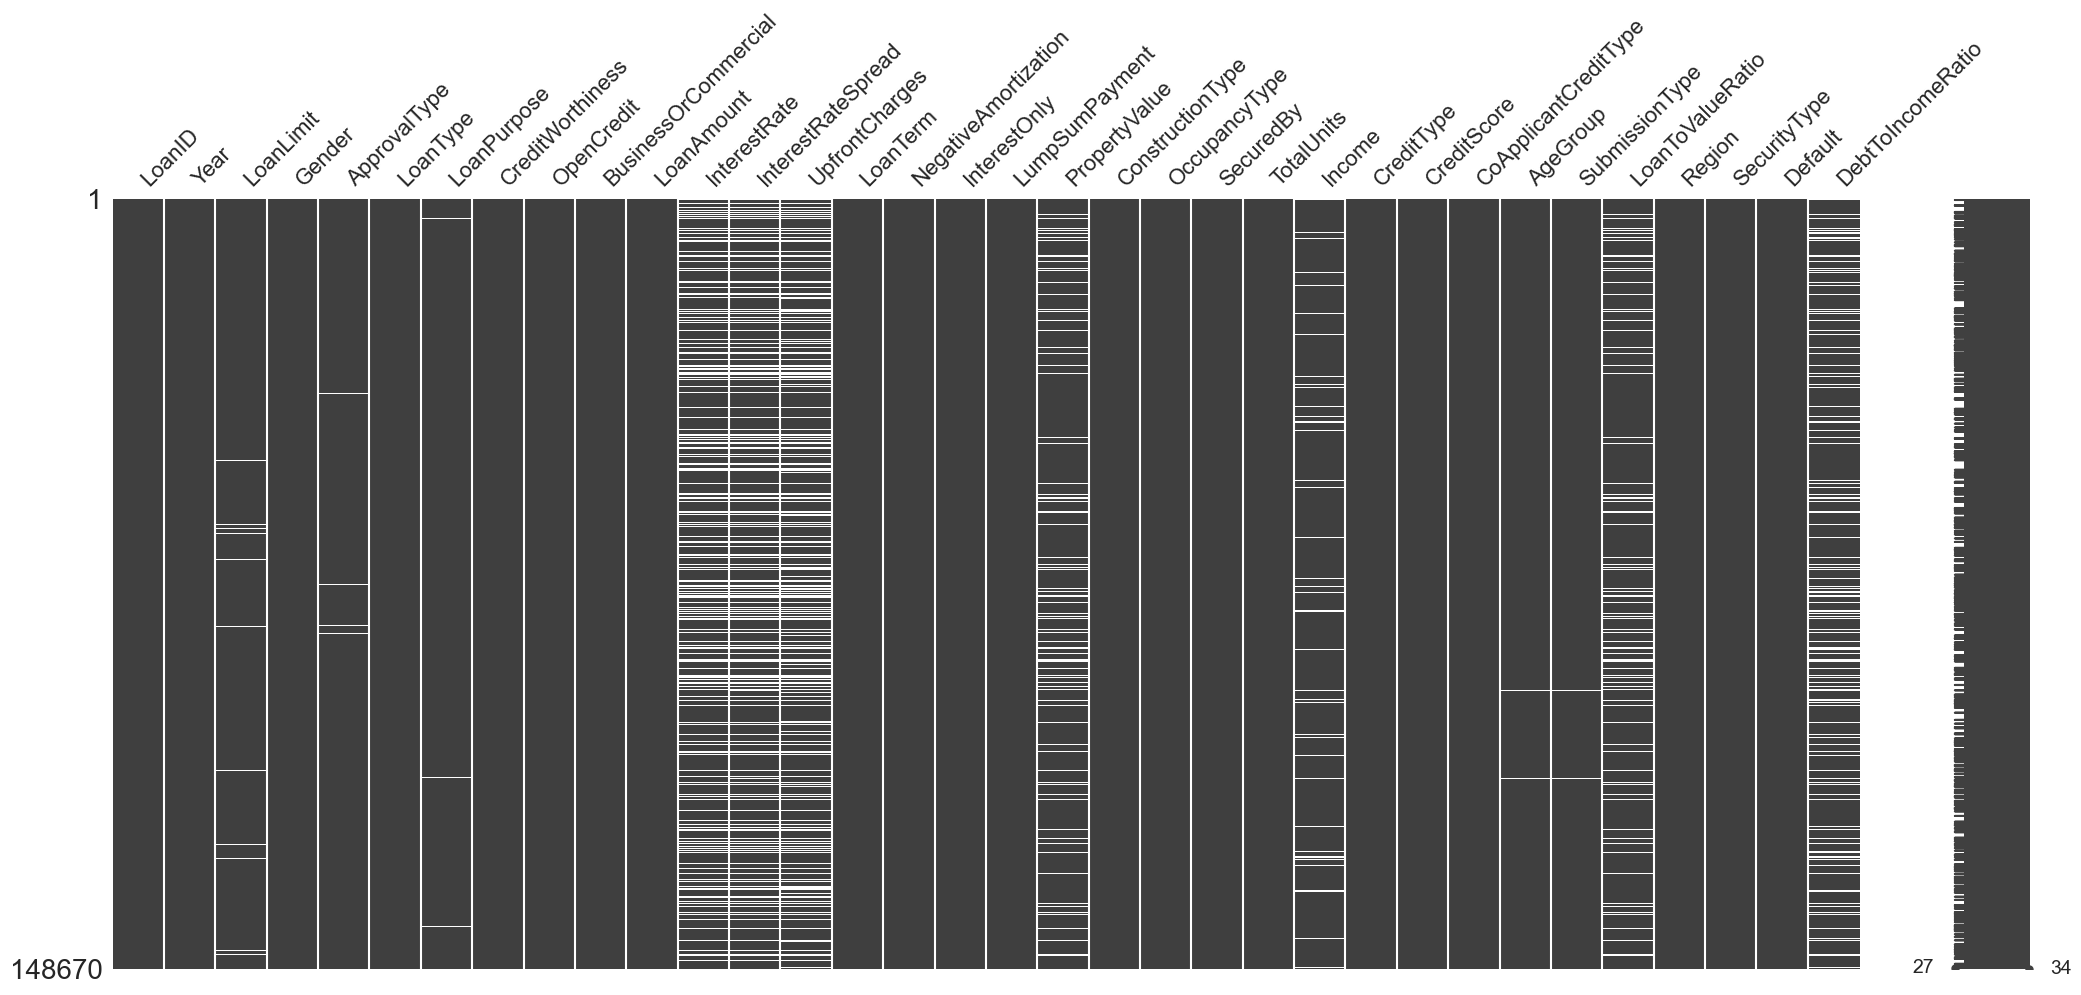

<Figure size 1500x900 with 0 Axes>

In [9]:
# Visualizing Null values (image)
msno.matrix(df)
plt.figure(figsize = (15,9))
plt.show()

The dataset contains a considerable number of missing values across several numerical and categorical features. Variables such as UpfrontCharges, InterestRateSpread, InterestRate, DebtToIncomeRatio, PropertyValue, and LoanToValueRatio contain a large number of missing observations that may negatively affect model performance if left untreated.

The missing values will be addressed separately based on feature type, beginning with numerical variables followed by categorical variables, using suitable imputation techniques to preserve data quality and consistency for predictive modeling. But only after the train-test split so that i won't cause data leakage.

### **5. Duplicated Data**

In [10]:
# Count duplicate rows
duplicates = df.duplicated().sum()
print('Duplicate Rows:', duplicates)

Duplicate Rows: 0


The dataset does not contain any duplicated rows. Therefore, no removal of duplicated data is required.

### **6. Drop Unimportant Column**

In [11]:
# Drop 'LoanID' and 'Year' columns as they are not useful for prediction
df.drop('LoanID', axis=1, inplace=True)
df.drop('Year', axis=1, inplace=True)

<br>

## **Exploratory Data Analysis (EDA)**

### **1. Target Variable Analysis**

Default
0    75.355485
1    24.644515
Name: proportion, dtype: float64

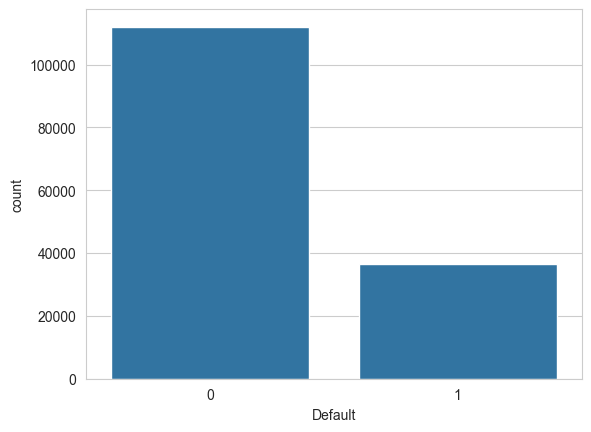

In [12]:
# Visualize target variable distribution
sns.countplot(x='Default', data=df)

# Display percentage distribution of target variable
df['Default'].value_counts(normalize=True) * 100

The data shows a clear imbalance: roughly 75% of people paid back their loans (0), while 25% defaulted (1). Because non-defaulters outnumber defaulters 3-to-1, a model that simply guesses "no default" every time would be 75% accurate while completely failing to catch the risky borrowers. To fix this, we cannot rely on accuracy metrics and must first handle the class imbalance in the pre-processing step.

### **2. Numerical Feature Analysis**

In [13]:
# Separate numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

##### **Distribution Analysis**

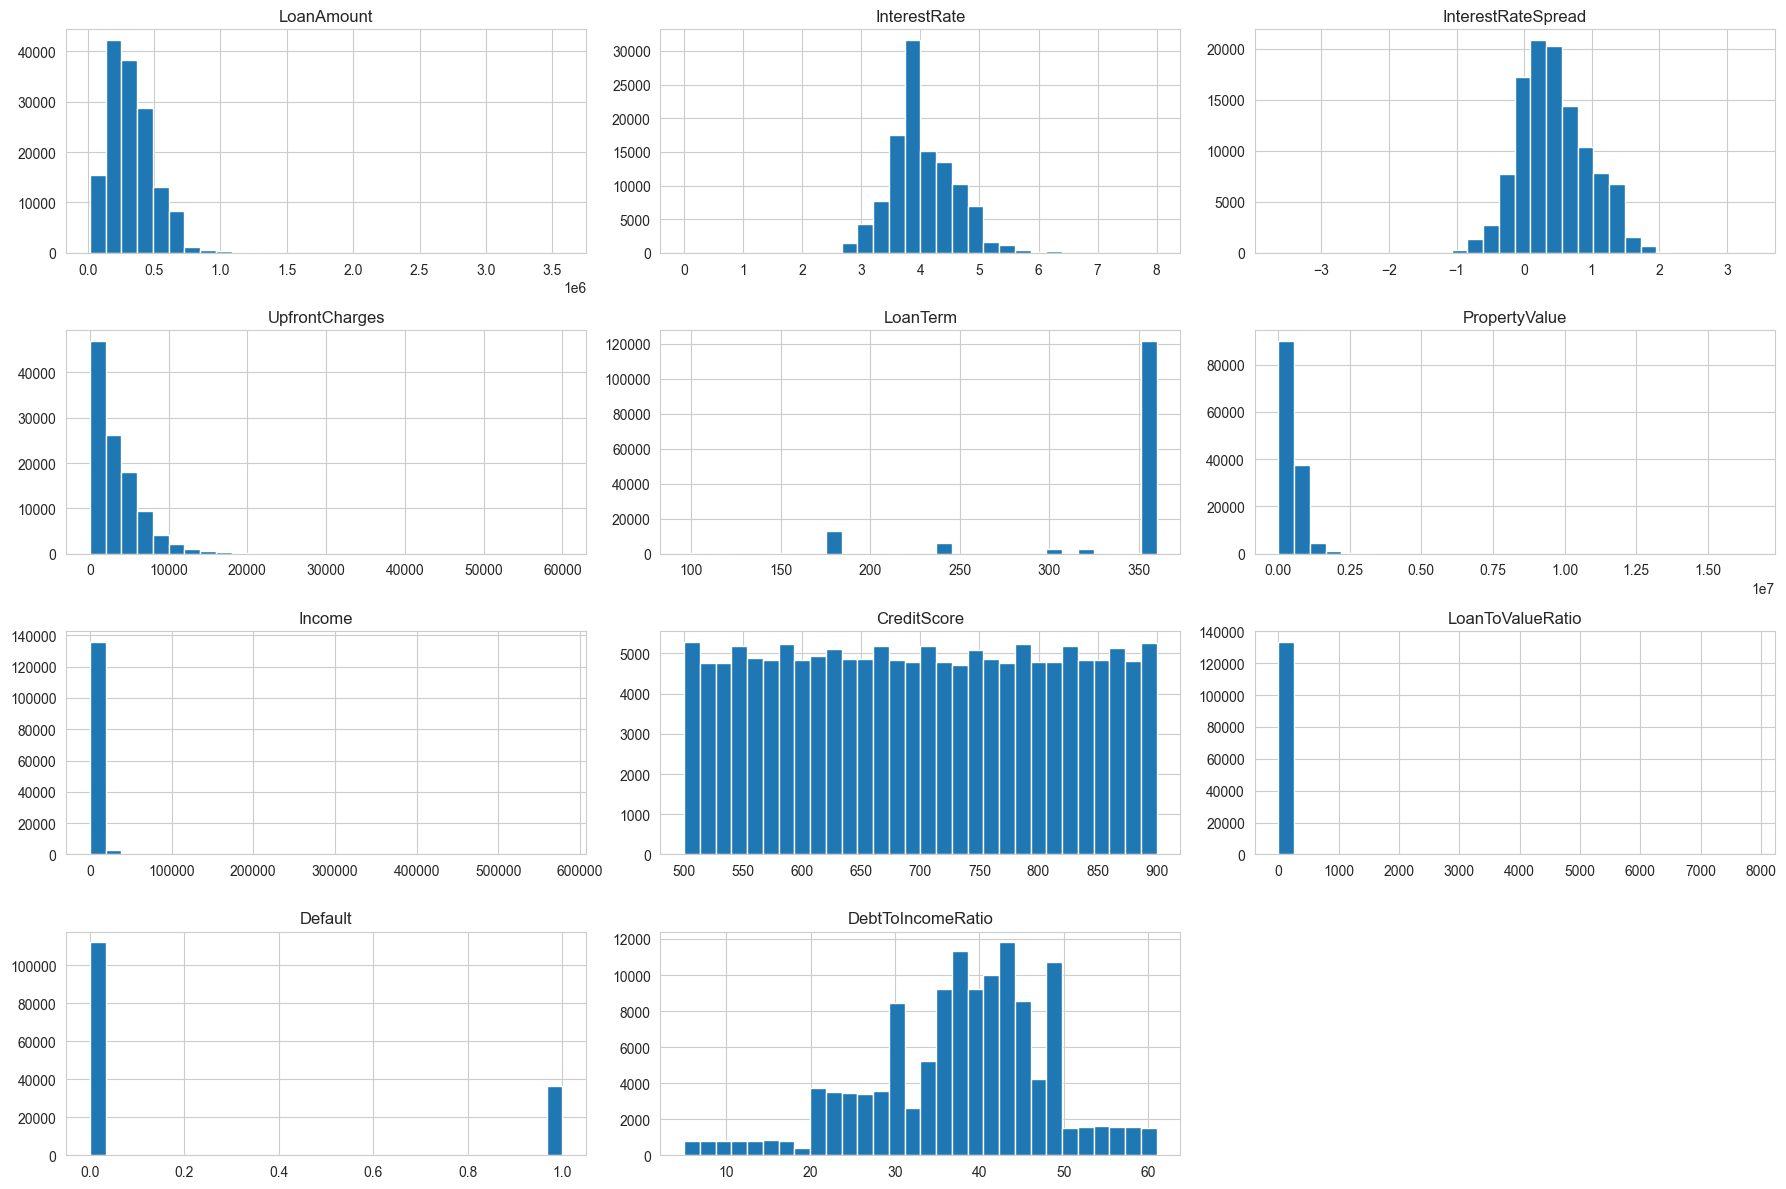

In [14]:
# Visualize distributions of numerical features
df[num_cols].hist(figsize=(18,12), bins=30)

plt.tight_layout()
plt.show()

The numerical features reveal key patterns. Most distributions are heavily skewed right, with LoanAmount, UpfrontCharges, PropertyValue, and Income showing a massive concentration of low-value loans alongside severe outliers that will require log transformations or robust scaling. LoanTerm behaves almost like a categorical variable since nearly all loans are concentrated at standard 360-month terms, while CreditScore is perfectly uniform, meaning it has an equal distribution of borrowers across all scores. Finally, InterestRate, InterestRateSpread, and DebtToIncomeRatio follow relatively normal distributions, but extreme outliers in LoanToValueRatio (stretching past 7,000) strongly point to data entry errors that must be capped or cleaned.

##### **Outlier Detection**

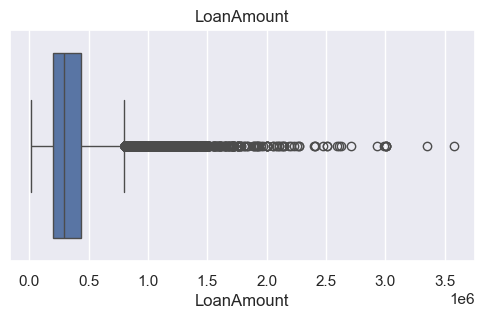

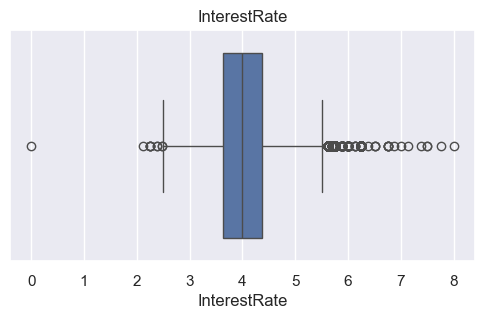

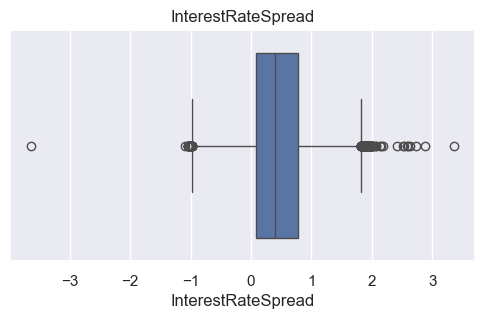

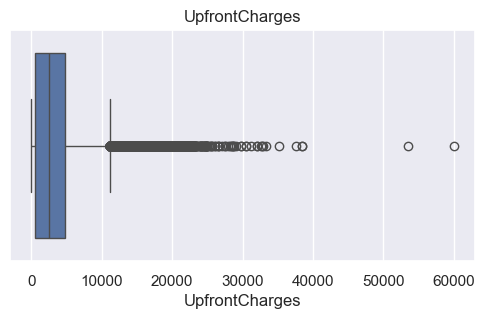

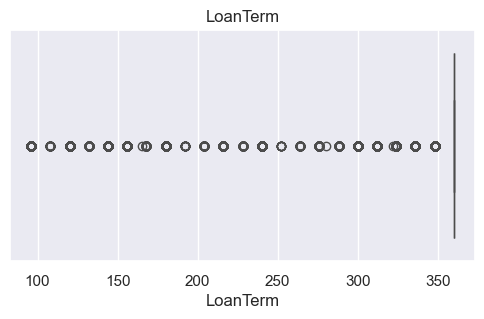

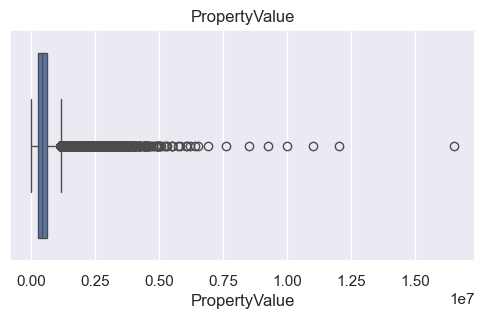

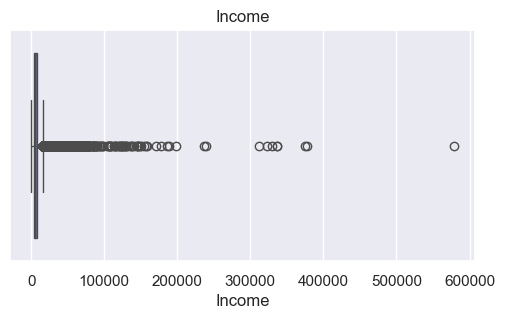

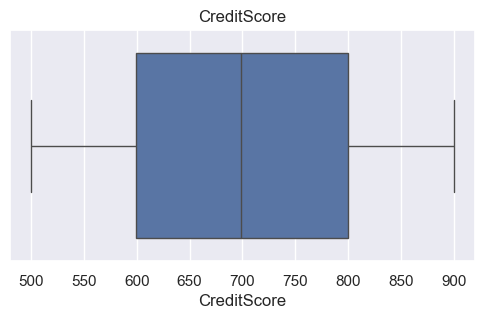

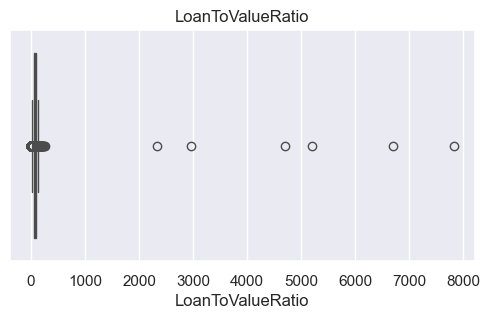

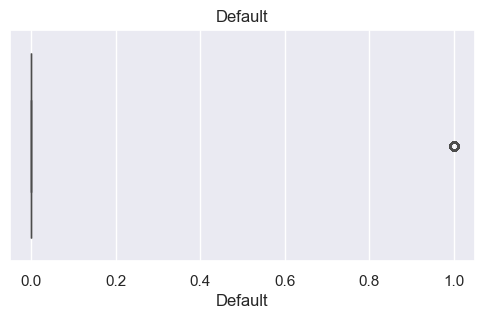

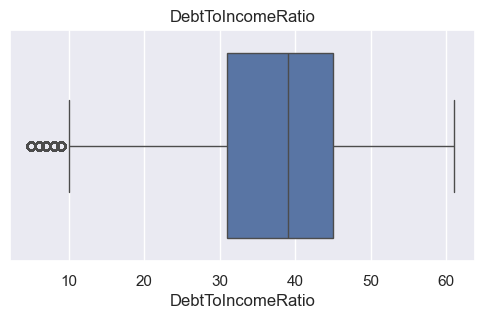

In [15]:
# Visualize numerical features against target variable
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.set_theme(style='darkgrid')
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

The boxplots confirm severe outlier and data quality issues that must be addressed during data preprocessing. Features like LoanAmount, UpfrontCharges, PropertyValue, and Income show heavy right-skewness with a dense, continuous trail of extreme high-value outliers that reflect genuine high-net-worth cases but will require log transformations or clipping to stabilize linear models. More critically, LoanToValueRatio displays extreme, physically impossible data anomalies reaching up to 8,000% alongside an unusual zero value for an InterestRate, proving the presence of major data entry errors that must be aggressively capped or filtered out. Meanwhile, CreditScore and DebtToIncomeRatio present relatively clean, well-bounded distributions, while LoanTerm reinforces its discrete nature, showing that virtually all variations exist exclusively as low-value outliers far below the standard 360-month median.

##### **Numerical Features vs Target**

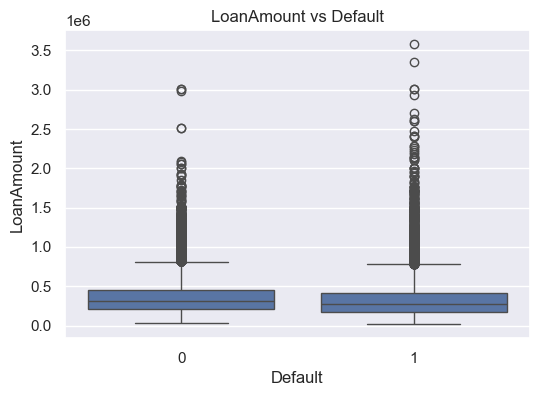

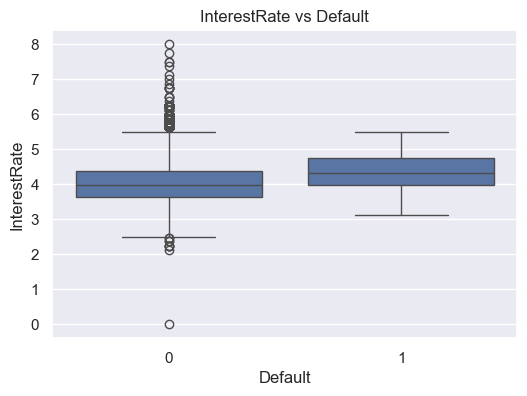

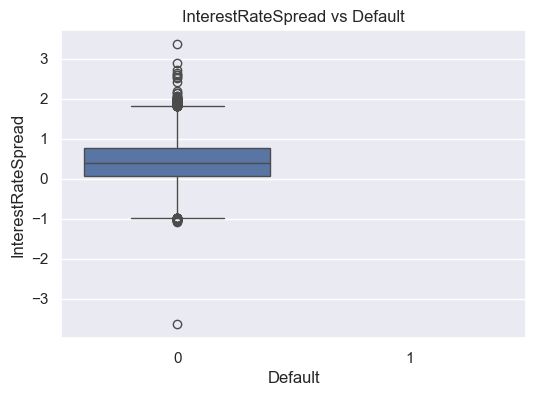

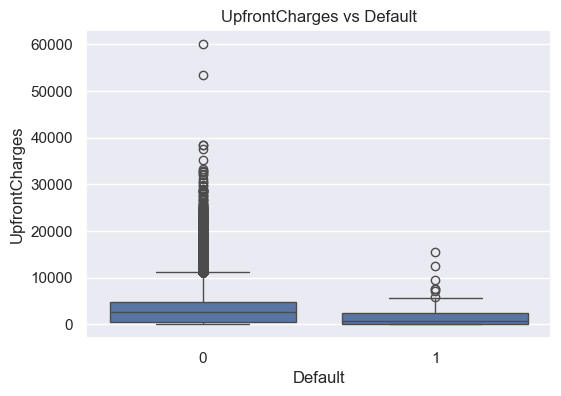

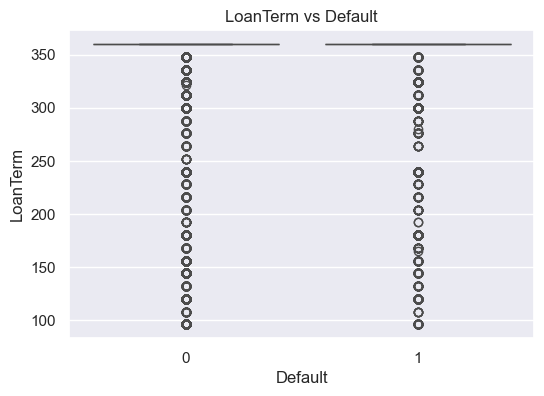

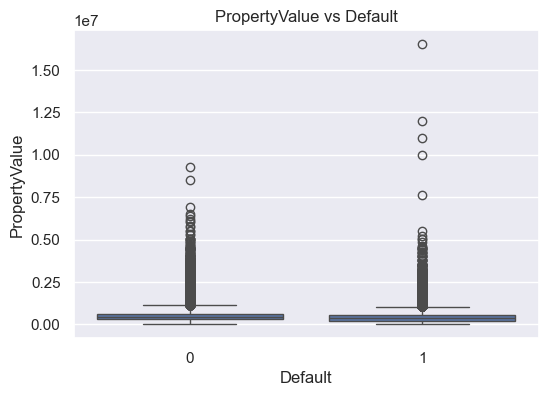

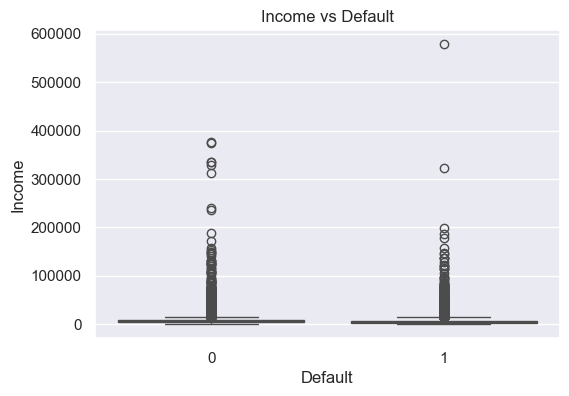

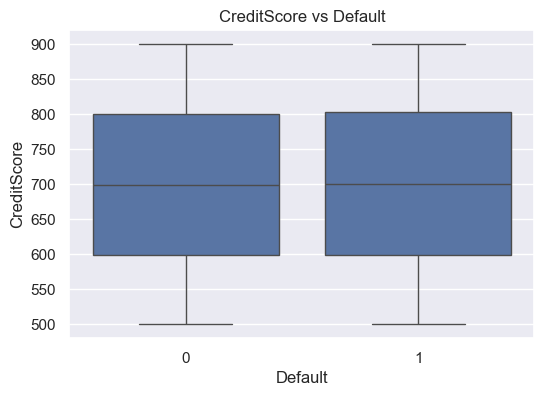

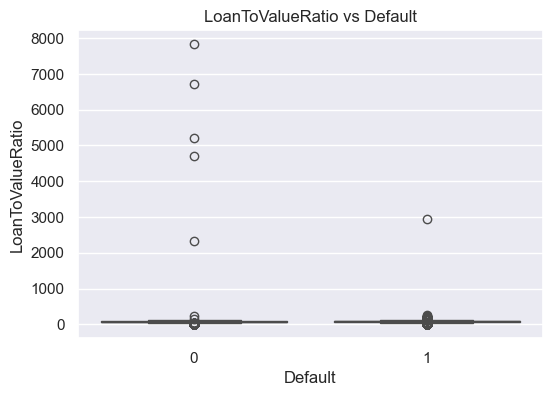

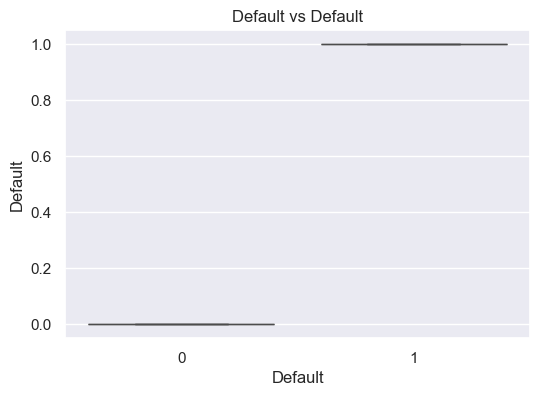

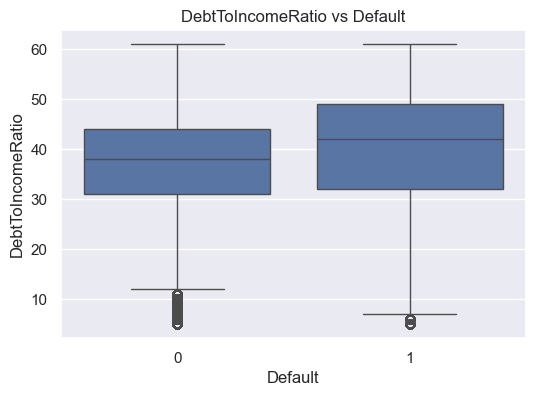

In [16]:
# Visualize numerical features against target variable
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.set_theme(style='darkgrid')
    sns.boxplot(
        x='Default',
        y=col,
        data=df
    )

    plt.title(f'{col} vs Default')
    plt.show()

The graphs show two main things that separate risky borrowers from safe ones:
- Higher Interest Rates: People who default (1) usually have higher interest rates. Higher rates mean higher monthly payments, which makes it harder to pay the loan back.
- Higher Debt-to-Income: Defaulters also tend to owe more money relative to what they earn. Having too much overall debt is a major warning sign.

On the other hand, CreditScore and LoanTerm look exactly the same for both groups, meaning they don't help separate them at a glance. For everything else like Income, LoanAmount, and PropertyValue, the graphs are flattened and messy because a few extreme high values (outliers) are crushing the data.

### **3. Categorical Feature Analysis**

In [17]:
# Separate categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

##### **Category Distributions**

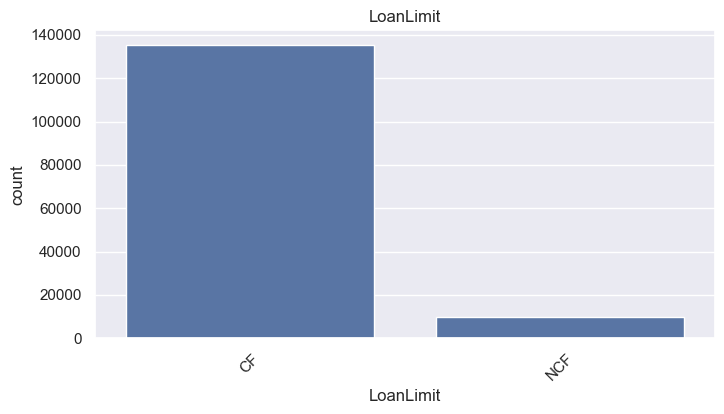

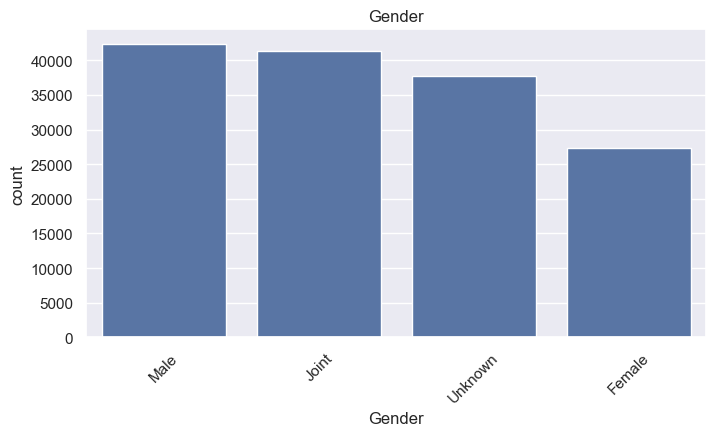

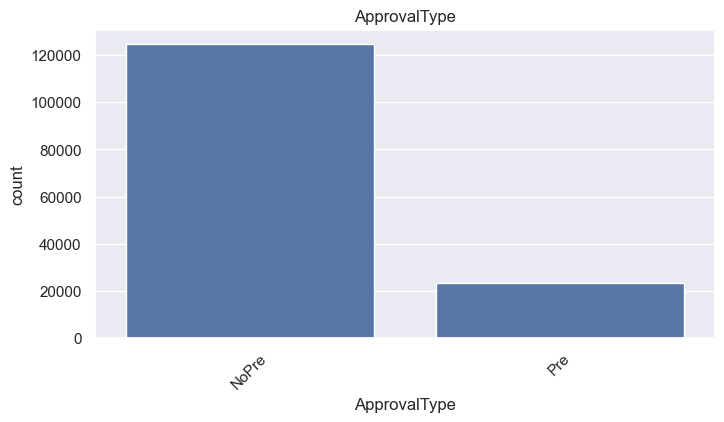

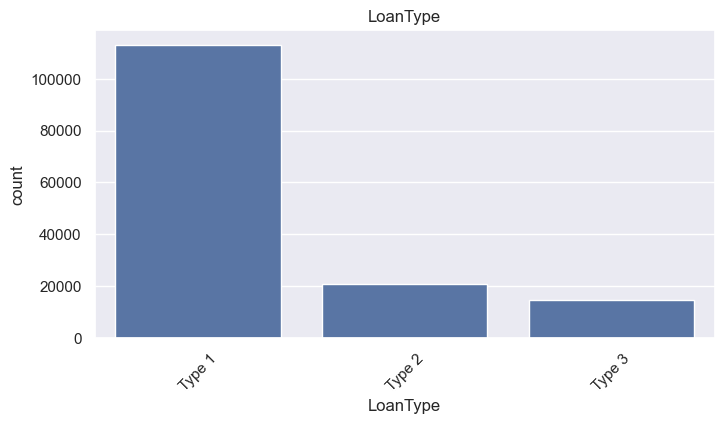

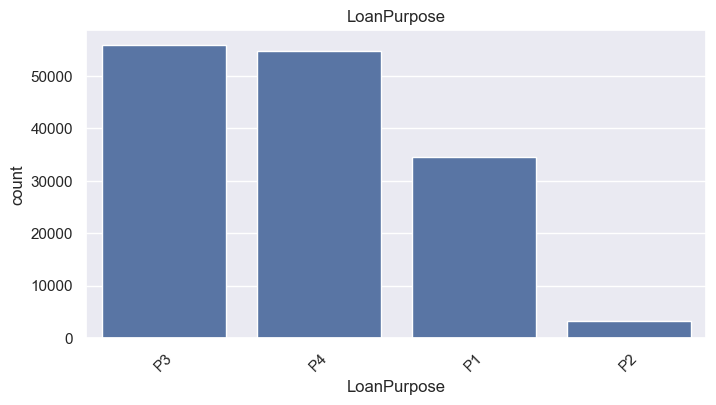

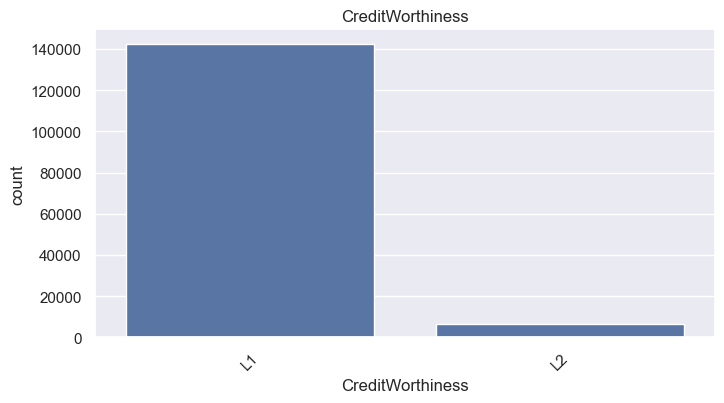

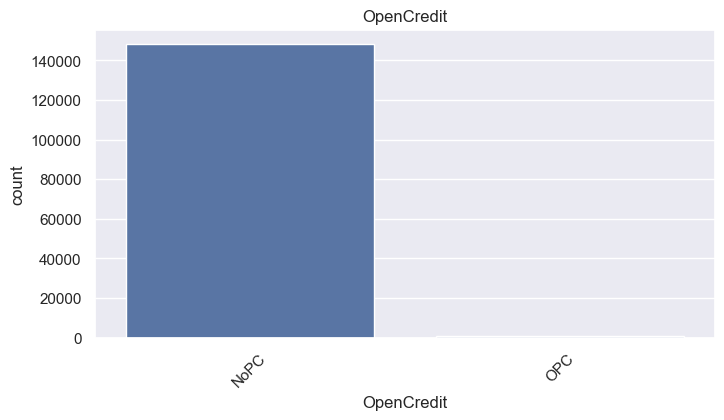

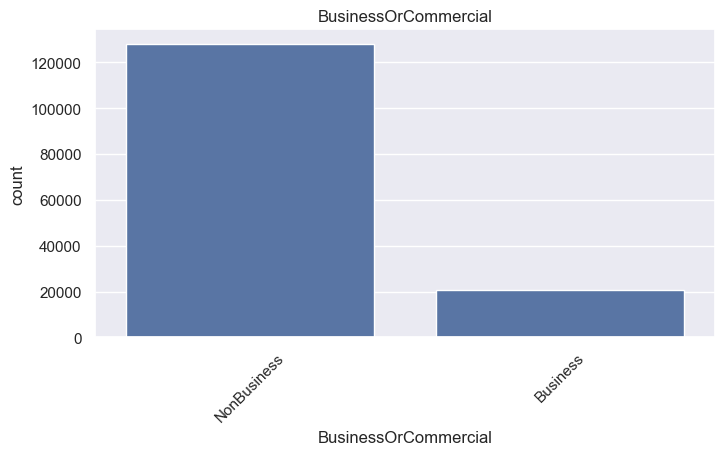

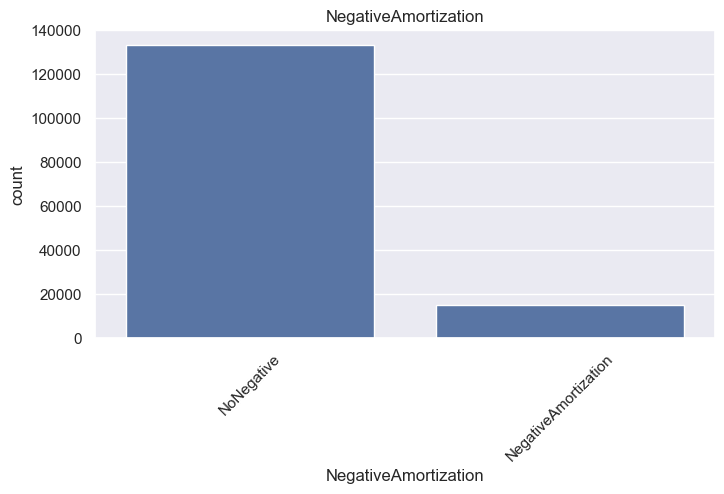

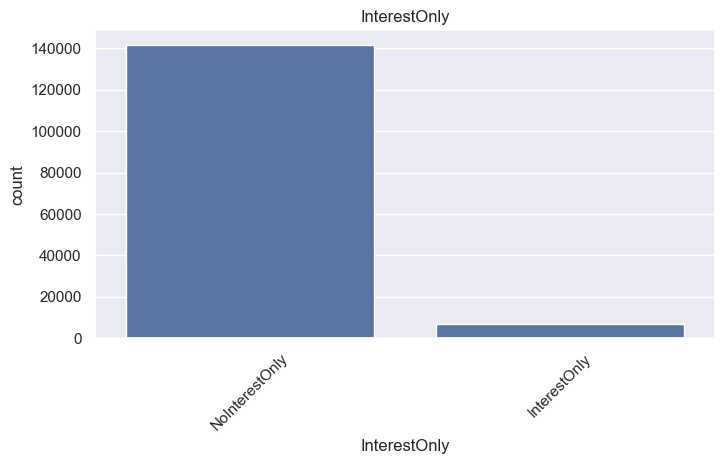

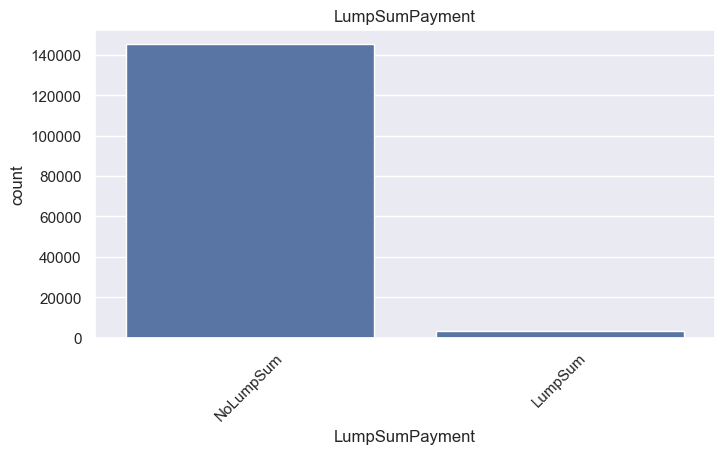

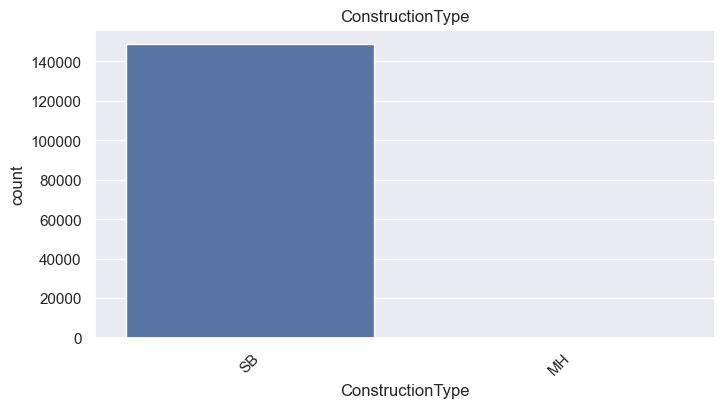

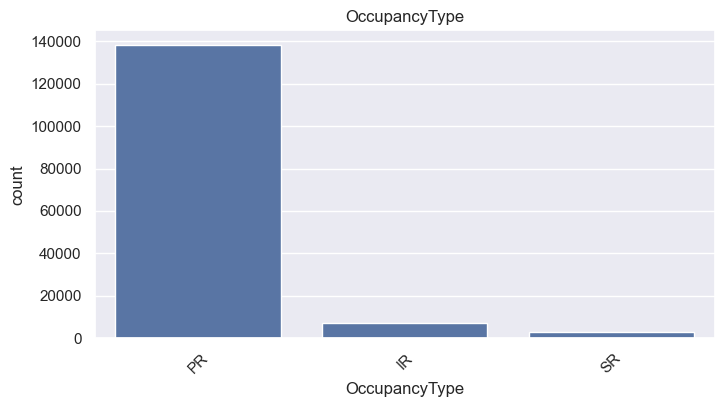

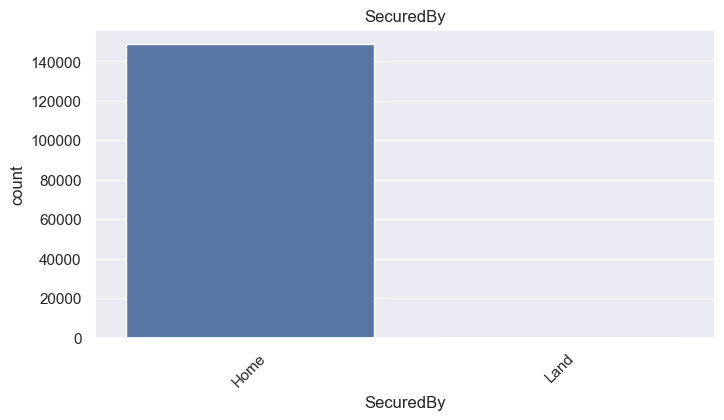

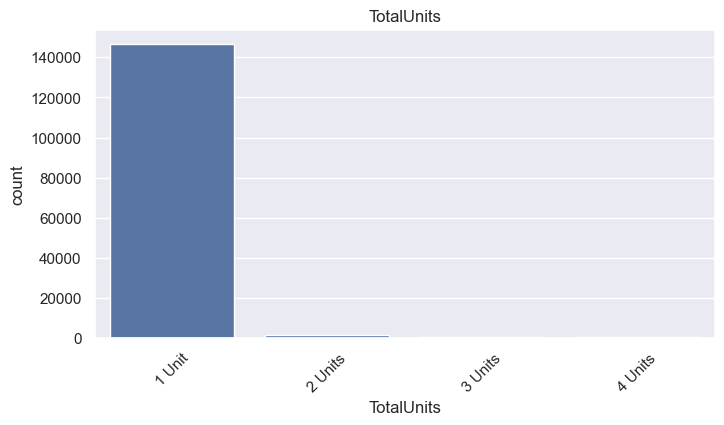

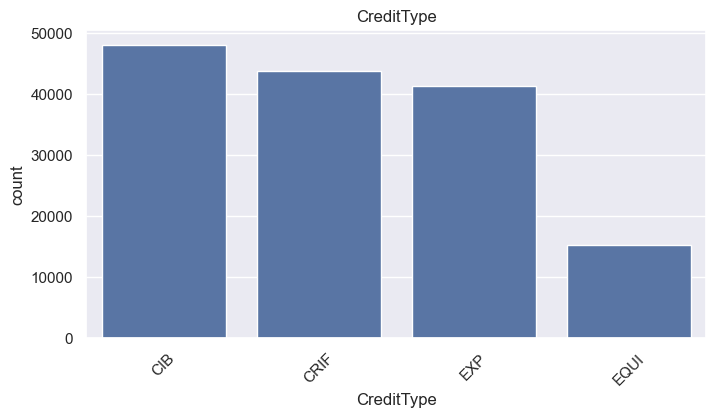

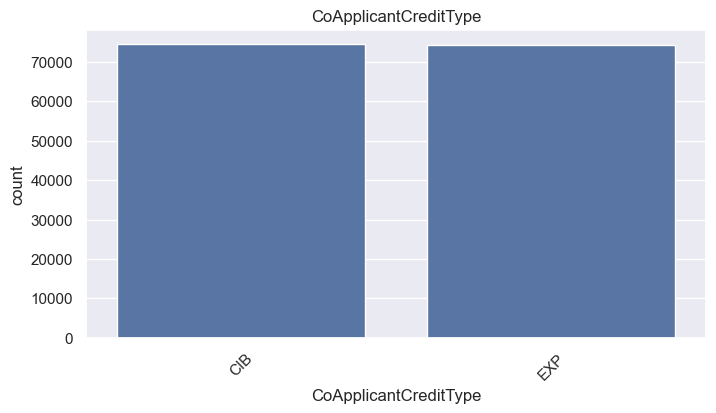

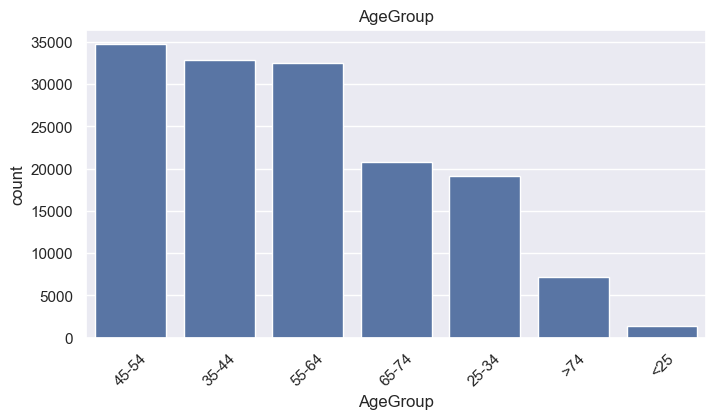

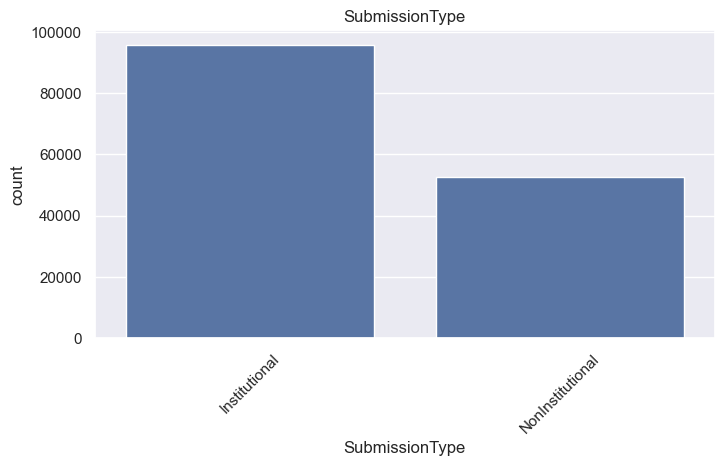

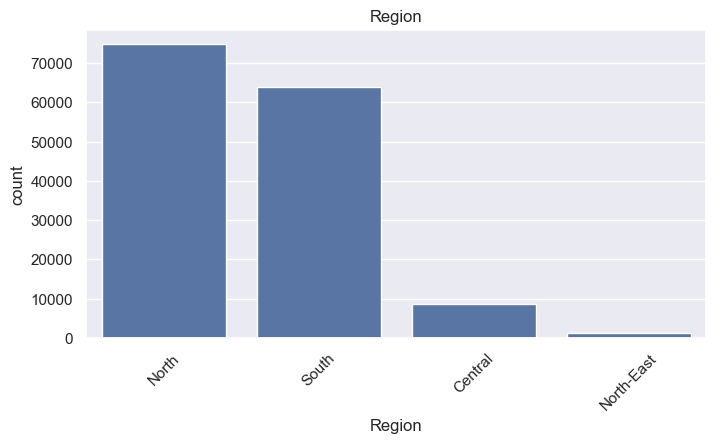

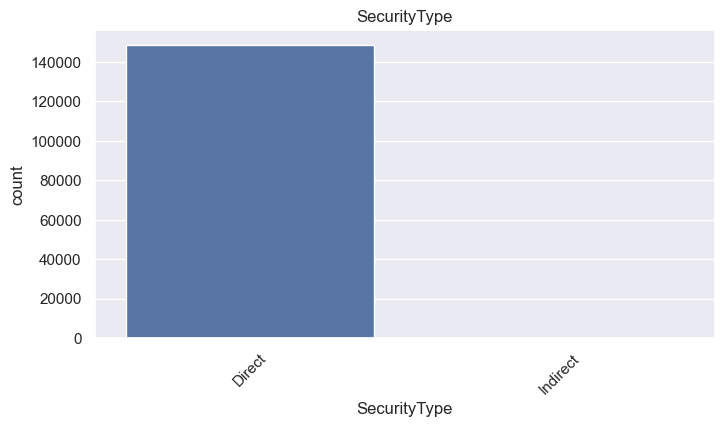

In [18]:
# Visualize categorical feature distributions
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.set_theme(style='darkgrid')
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

The charts provide some meaningful insights:

- Extreme Imbalances (One-Sided Data): A massive majority of the features are heavily dominated by just a single category. For example, almost every single record in the dataset is for a standard home (Home), a single-family property (1 Unit), a traditional building style (SB), and loans without upfront lump-sum payments (NoLumpSum). Just like the LoanLimit, OpenCredit, and InterestOnly columns from the first batch, these columns are so heavily skewed that the tiny minority groups won't give the model much information to work with.

- Healthy, Diverse Data: On the bright side, columns like AgeGroup, CreditType, and Region are spread out much more naturally. The data mostly represents people between 35 and 64 years old, spread across the North and South regions, using a healthy mix of different credit reporting types (CIB, CRIF, and EXP). CoApplicantCreditType and SubmissionType also show a clean, healthy split between their main categories.

##### **Categorical Features vs Target**

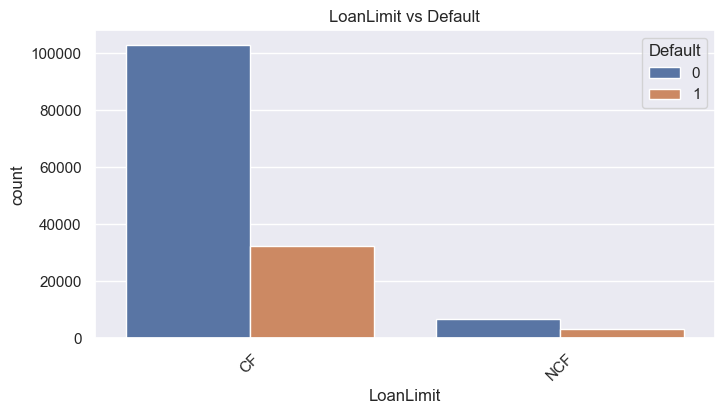

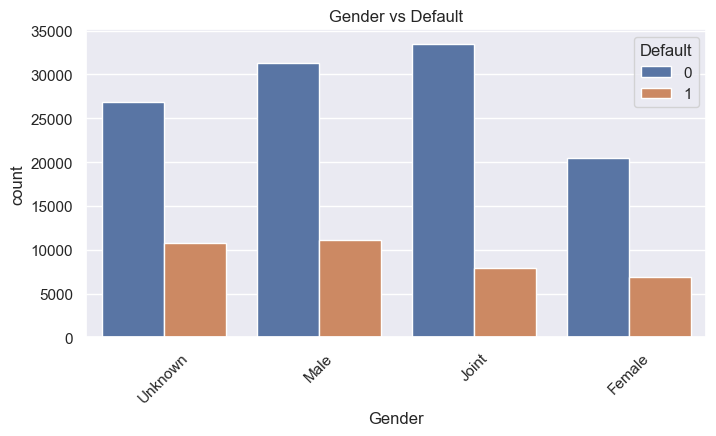

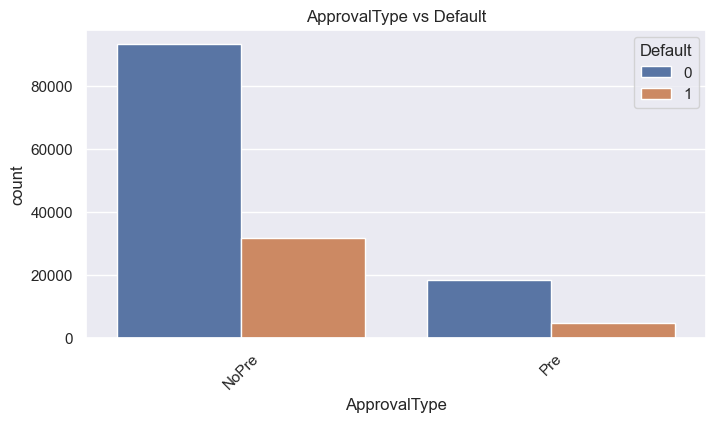

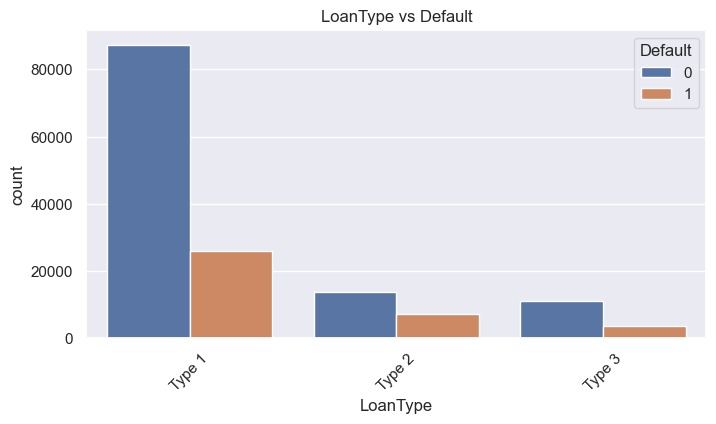

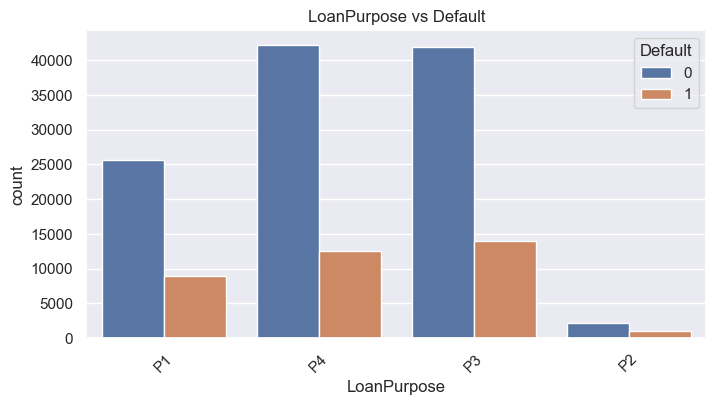

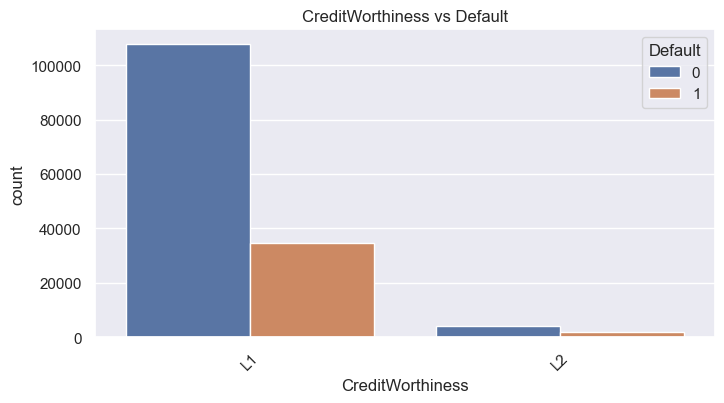

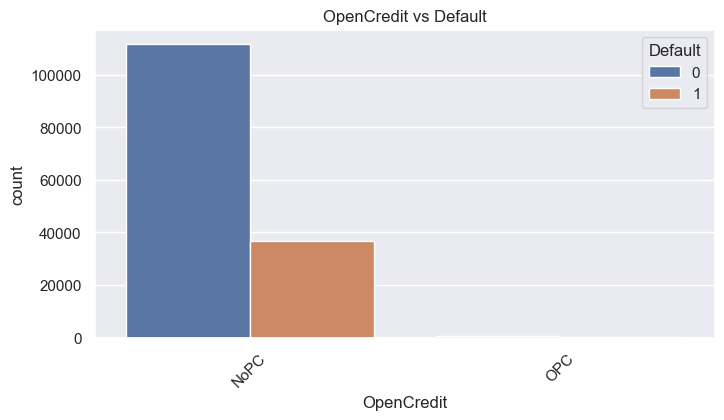

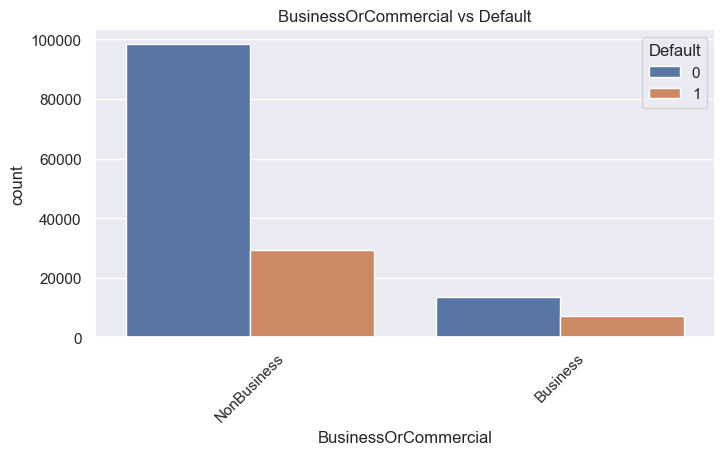

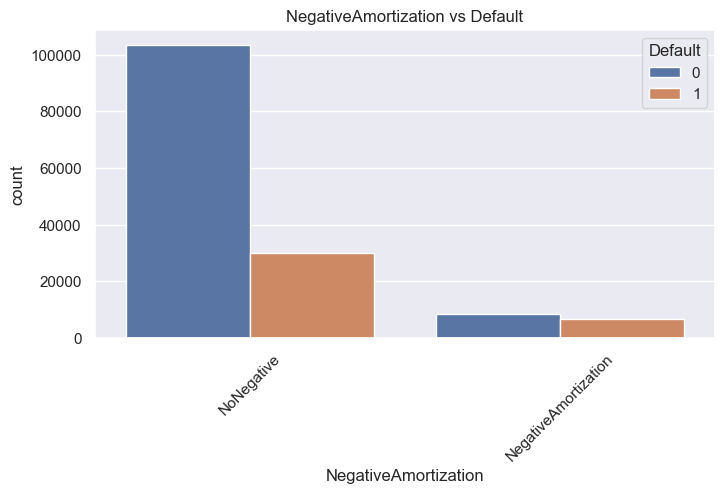

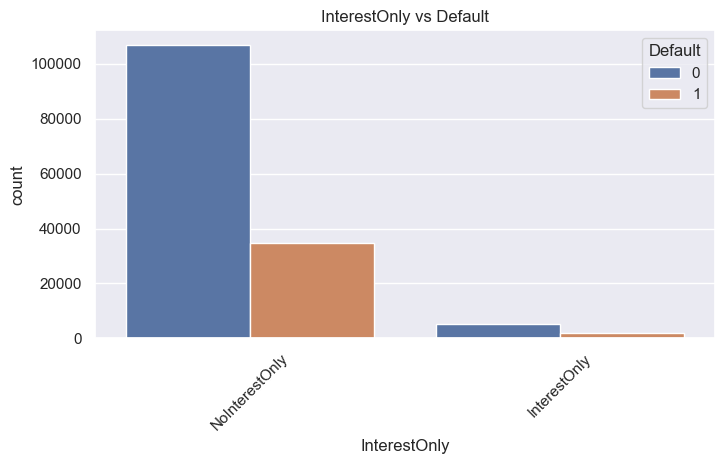

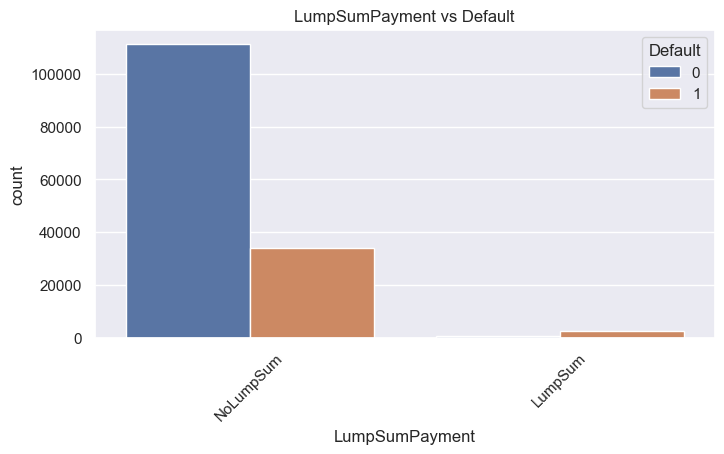

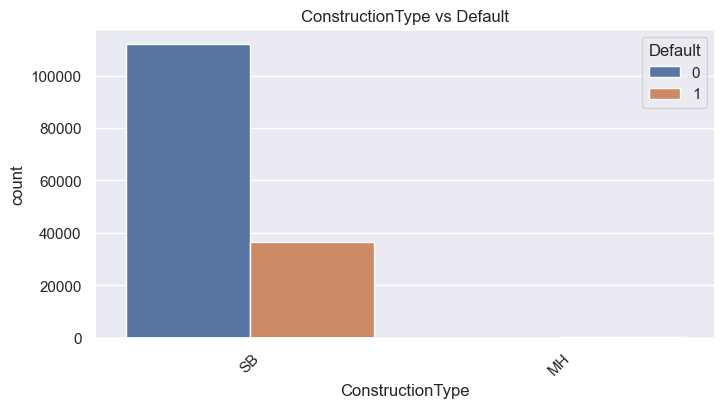

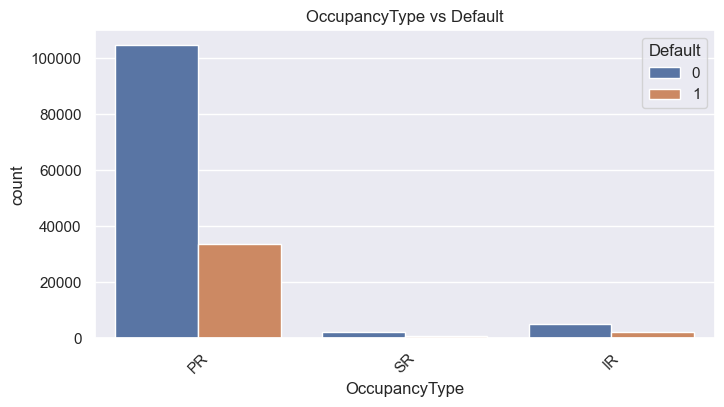

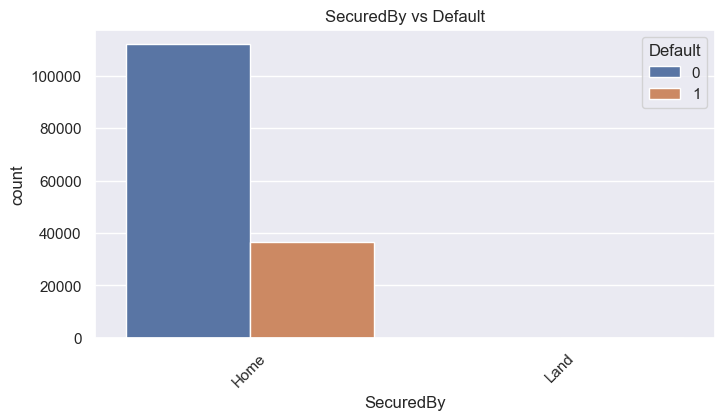

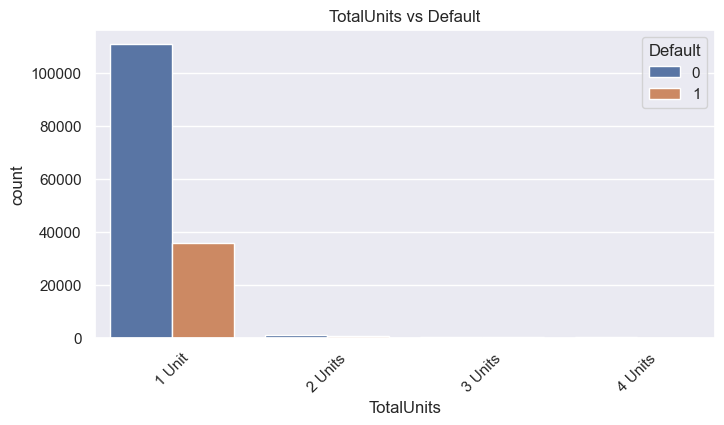

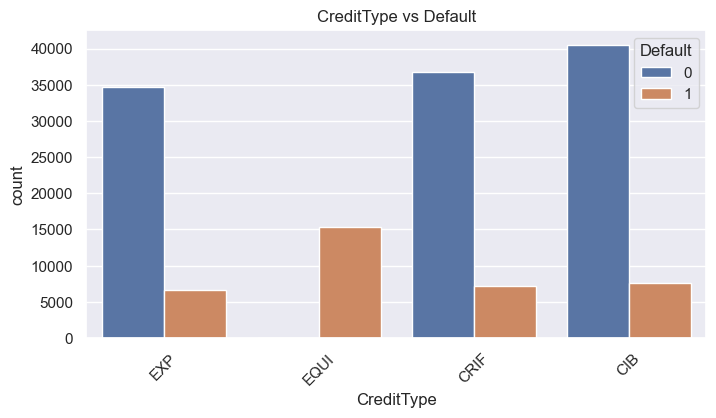

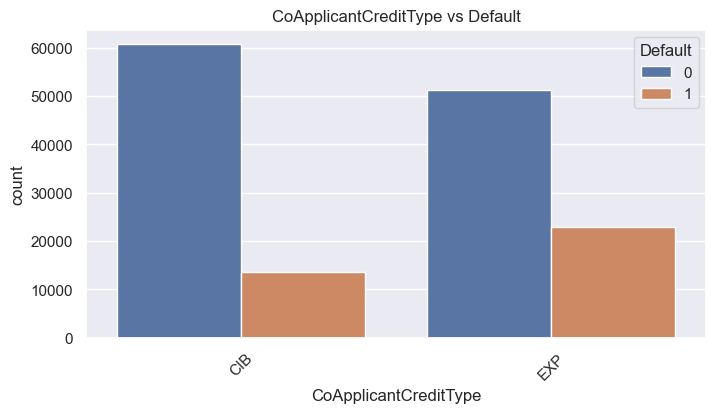

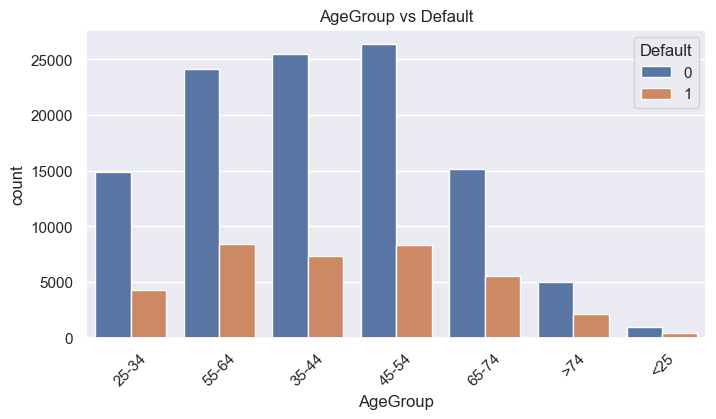

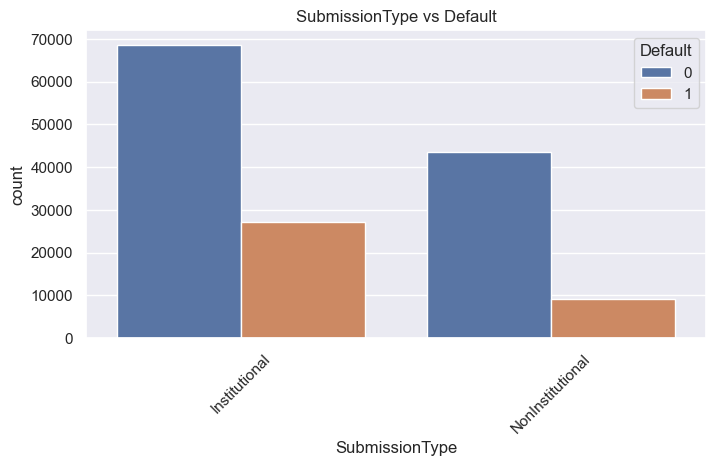

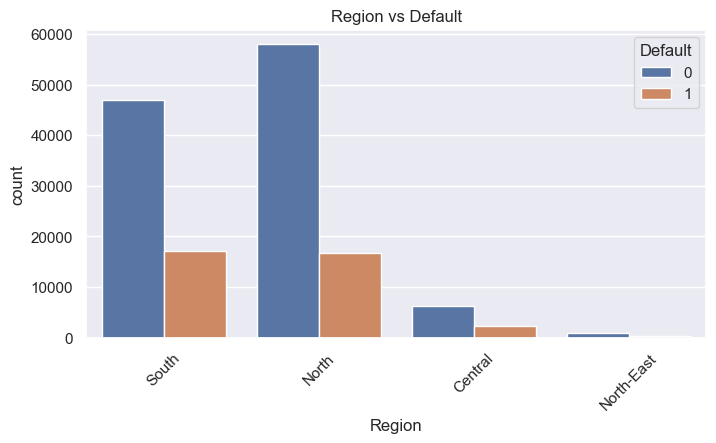

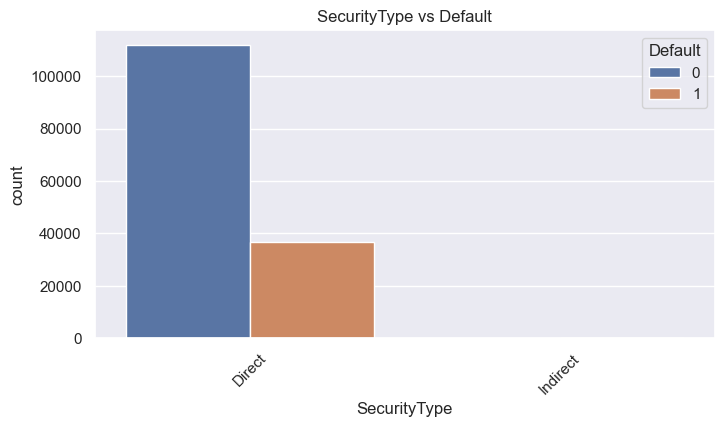

In [19]:
# Visualize categorical features against target variable
for col in cat_cols:

    plt.figure(figsize=(8,4))
    sns.set_theme(style='darkgrid')
    sns.countplot(
        data=df,
        x=col,
        hue='Default'
    )

    plt.xticks(rotation=45)
    plt.title(f'{col} vs Default')
    plt.show()


From the charts above, we can get some indicators on what factors make the customer more likely to default:
- EQUI Credit Type: Borrowers marked with this credit type default almost 100% of the time. This is your single strongest categorical indicator of risk.
- EXP Co-Applicants: Loans where the co-applicant has an "EXP" credit type have a significantly higher rate of default.
- The "Unknown" Gender Group: Even though "Unknown" represents missing data, a very large chunk of these borrowers end up defaulting. Missing information in this dataset is a genuine warning sign.
- Southern Region: Borrowers from the South default at a noticeably higher rate relative to the number of loans issued there compared to the North.
- Institutional Submissions: Borrowers who submit their applications institutionally show a higher share of defaults.

On the other hand we can also see the pattern for customers who are more likely to not default:
- Joint Applicants: People applying together with a partner ("Joint") are the least likely to default out of all the gender categories.
- Type 3 Loans & P2 Purposes: The people who get them have incredibly low default rates (Rare in the data though).

### **4. Correlation Analysis**

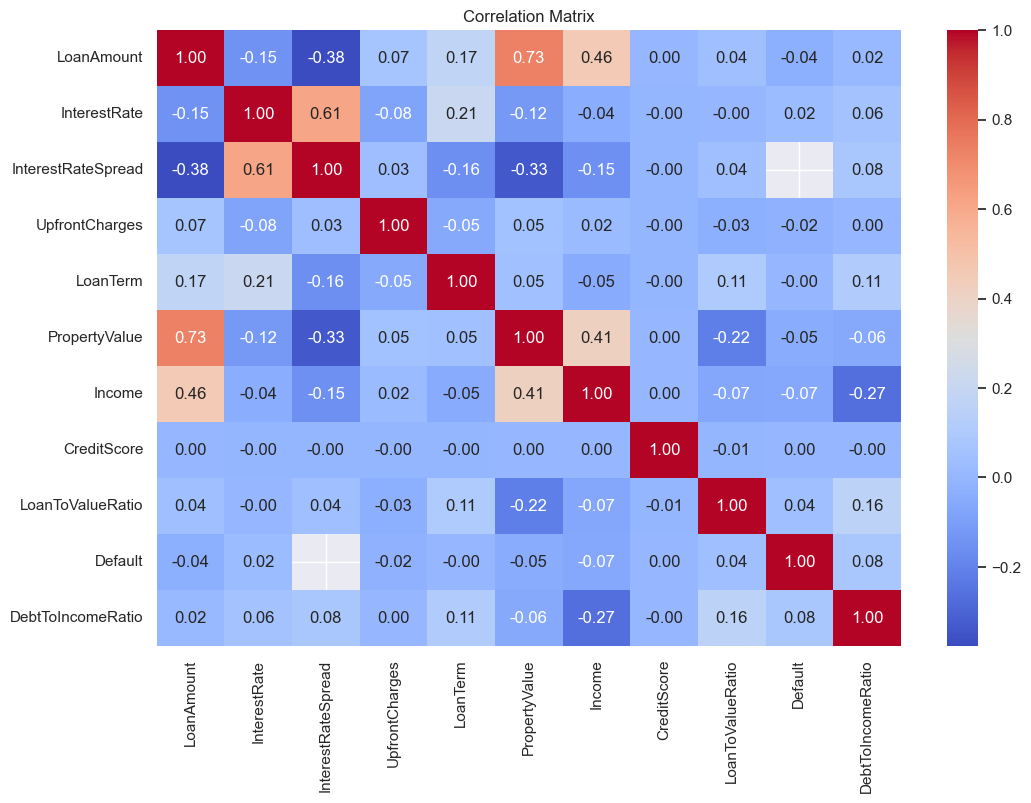

In [20]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

Based on the correlation matrix we can see some patterns:
- LoanAmount vs. PropertyValue (0.73): There is a strong positive correlation here. Bigger loans are naturally tied to more expensive properties.
- InterestRate vs. InterestRateSpread (0.61): These two are also highly correlated.
- LoanAmount vs. Income (0.46) & PropertyValue vs. Income (0.41): People with higher incomes predictably buy more expensive homes and take out larger loans.
- Default correlations look incredibly weak: On paper, every single numerical feature shows a near-zero correlation with Default (all between -0.07 and 0.08).

### **5. Key Insights**

Target Variable Distribution and Imbalance
- There is a major class imbalance in the data, with 75.4% of borrowers paying back their loans and 24.6% defaulting (roughly a 3-to-1 ratio).

High-Risk Red Flags (More likely to default)
- Borrowers who default show visibly higher median interest rates and higher debt-to-income ratios, meaning heavy financial strain scales directly with default risk.
- Borrowers marked with the "EQUI" credit type default almost 100% of the time, making it the single strongest warning sign in the dataset.
- Loans where the co-applicant has an "EXP" credit type experience significantly higher default rates.
- While the North region accounts for the highest total volume of loans, applications originating from the South carry a noticeably higher default ratio relative to their size.
- The "Unknown" gender group contains an unusually high concentration of defaults. This proves that missing data fields are not completely random and contain an important signal that must be kept as a standalone category.

Low-Risk Groups (Safest borrowers)
- People applying together with a partner ("Joint") are the least likely to default out of all the demographic groups.
- "Type 3" loans and loans intended for the "P2" purpose are quite rare in the dataset, but when they do appear, they consistently register exceptionally low default rates.

## **Data Pre-Processing**

### **1. Train-Test Split**

In [21]:
# Separate features and target variable
X = df.drop('Default', axis=1)
y = df['Default']

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes of training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Display target variable distribution in training and testing sets
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (118936, 31)
X_test shape: (29734, 31)
y_train shape: (118936,)
y_test shape: (29734,)
Training target distribution:
Default
0    0.753557
1    0.246443
Name: proportion, dtype: float64

Testing target distribution:
Default
0    0.753548
1    0.246452
Name: proportion, dtype: float64


### **2. Impute Missing Data**

In [22]:
# Separate numerical and categorical columns in training set
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

cat_cols = X_train.select_dtypes(
    include=['object']
).columns.tolist()

#### **Numerical Imputation using KNNImputer**

In [23]:
knn_imputer = KNNImputer(n_neighbors=3)

# Impute missing values in numerical columns using KNN imputer
X_train[num_cols] = knn_imputer.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = knn_imputer.transform(
    X_test[num_cols]
)

#### **Categorical Imputation using Most Frequent Class**

In [24]:
cat_imputer = SimpleImputer(strategy='most_frequent')

# Impute missing values in categorical columns using most frequent strategy
X_train[cat_cols] = cat_imputer.fit_transform(
    X_train[cat_cols]
)

X_test[cat_cols] = cat_imputer.transform(
    X_test[cat_cols]
)

#### **Verify there's no missing value**

In [25]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


### **3. Outliers handling using Winsorization**

#### **Create copies for Outlier Handling**

In [26]:
# Create copies of training and testing sets for outlier handling
X_train_outlier = X_train.copy()
X_test_outlier = X_test.copy()

# Separate numerical columns in outlier handling sets
num_cols = X_train_outlier.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

#### **Winsorization / Outlier Capping**

In [27]:
for col in num_cols:

    # Calculate Q1 and Q3 for the training data
    Q1 = X_train_outlier[col].quantile(0.25)
    Q3 = X_train_outlier[col].quantile(0.75)

    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap training data
    X_train_outlier[col] = np.where(
        X_train_outlier[col] < lower_bound,
        lower_bound,
        X_train_outlier[col]
    )

    X_train_outlier[col] = np.where(
        X_train_outlier[col] > upper_bound,
        upper_bound,
        X_train_outlier[col]
    )

    # Cap testing data using TRAIN bounds
    X_test_outlier[col] = np.where(
        X_test_outlier[col] < lower_bound,
        lower_bound,
        X_test_outlier[col]
    )

    X_test_outlier[col] = np.where(
        X_test_outlier[col] > upper_bound,
        upper_bound,
        X_test_outlier[col]
    )

#### **Verify with Boxplots**

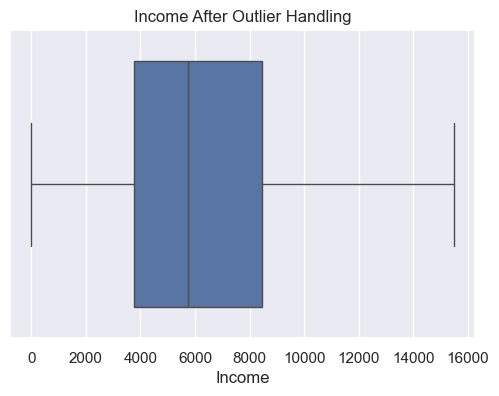

In [28]:
# Visualize 'Income' distribution after outlier handling
plt.figure(figsize=(6,4))
sns.boxplot(x=X_train_outlier['Income'])
plt.title("Income After Outlier Handling")
plt.show()

#### **Renew Original Dataframe**

In [29]:
X_train = X_train_outlier
X_test = X_test_outlier

### **3. Outliers handling using Winsorization**

In [30]:
# Separate numerical and categorical columns in training set
cat_cols = X_train.select_dtypes(
    include=['object']
).columns.tolist()

# Initialize OneHotEncoder with handle_unknown='ignore' to avoid errors during transformation
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Fit encoder on training data and transform both training and testing data
X_train_encoded = encoder.fit_transform(
    X_train[cat_cols]
)

X_test_encoded = encoder.transform(
    X_test[cat_cols]
)

# Get encoded feature names
encoded_cols = encoder.get_feature_names_out(cat_cols)

# Create DataFrames for encoded features
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

# Create DataFrame for encoded test features
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

# Drop original categorical columns from training and testing sets
X_train_num = X_train.drop(columns=cat_cols)
X_test_num = X_test.drop(columns=cat_cols)

# Concatenate numerical and encoded categorical features to create final training and testing sets
X_train_final = pd.concat(
    [X_train_num, X_train_encoded_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test_num, X_test_encoded_df],
    axis=1
)

# Display shapes of final training and testing sets
print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)

print(X_train_final.dtypes.value_counts())

X_train_final shape: (118936, 69)
X_test_final shape: (29734, 69)
float64    69
Name: count, dtype: int64


### **4. Scaling using StandardScaler**

In [31]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale numerical features in training and testing sets
X_train_scaled = scaler.fit_transform(
    X_train_final
)

X_test_scaled = scaler.transform(
    X_test_final
)

# Display shapes and mean of scaled training and testing sets
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(X_train_scaled.mean())


(118936, 69)
(29734, 69)
7.517398528990252e-17


### **5. Class Balancing using Class Weights**

In [32]:
# Display class distribution in training set
print(y_train.value_counts())
print("\nClass Proportions:")
print(y_train.value_counts(normalize=True))



Default
0    89625
1    29311
Name: count, dtype: int64

Class Proportions:
Default
0    0.753557
1    0.246443
Name: proportion, dtype: float64


In [33]:
# Compute class weights to handle class imbalance
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

In [34]:
# Create a dictionary mapping class labels to their corresponding weights
class_weight_dict = dict(
    zip(classes, class_weights)
)

print(class_weight_dict)

{0: 0.6635202231520223, 1: 2.028862884241411}


## **Model Building**

### **1. XGBoost Model**

#### **Import Libraries**

In [35]:
# Initialize XGBoost Classifier 
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

#### **Initialize and Train Model**

In [36]:
# Initialize XGBoost Classifier 
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Change column names to remove special characters for XGBoost compatibility
X_train_final.columns = (
    X_train_final.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)

X_test_final.columns = (
    X_test_final.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)

# Fit the model on the training data
xgb_model.fit(
    X_train_final,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

#### **Predictions**

In [37]:
# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test_final)
y_prob_xgb = xgb_model.predict_proba(X_test_final)[:,1]

#### **Evaluation**

Accuracy:
0.9758861908925809

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     22406
           1       0.98      0.92      0.95      7328

    accuracy                           0.98     29734
   macro avg       0.98      0.96      0.97     29734
weighted avg       0.98      0.98      0.98     29734


ROC-AUC Score:
0.9925788030206352


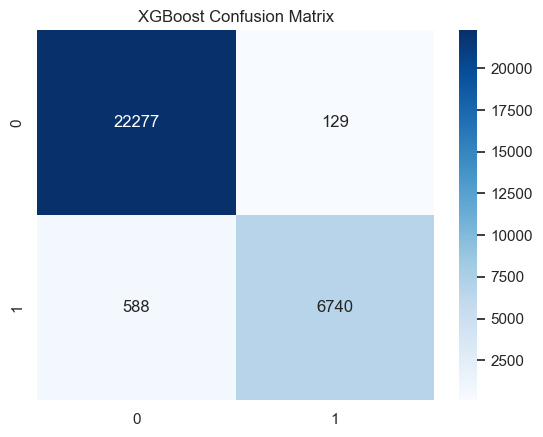

In [38]:
# Evaluate model performance
print("Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_xgb))

# Visualize confusion matrix
sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")
plt.show()

### **2. Artificial Neural Network (ANN) Model**

#### **Import Libraries**

In [39]:
# Initialize and train a simple neural network using TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

#### **Build and Compile Model**

In [40]:
# Build a simple ANN model
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### **Train ANN and Predict**

In [41]:
# Train the model with class weights to handle imbalance
history_ann = ann_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

# Predict probabilities and classes for the test set
y_prob_ann = ann_model.predict(X_test_scaled)
y_pred_ann = (y_prob_ann > 0.5).astype(int)

Epoch 1/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8508 - loss: 0.3978 - val_accuracy: 0.8957 - val_loss: 0.2808
Epoch 2/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 968us/step - accuracy: 0.8843 - loss: 0.3243 - val_accuracy: 0.9058 - val_loss: 0.2713
Epoch 3/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 994us/step - accuracy: 0.8911 - loss: 0.2991 - val_accuracy: 0.9025 - val_loss: 0.2695
Epoch 4/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 974us/step - accuracy: 0.8947 - loss: 0.2890 - val_accuracy: 0.9094 - val_loss: 0.2435
Epoch 5/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 984us/step - accuracy: 0.8968 - loss: 0.2817 - val_accuracy: 0.9118 - val_loss: 0.2339
Epoch 6/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8990 - loss: 0.2756 - val_accuracy: 0.9090 - val_loss: 0.2352
Epoch 7/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8991 - loss: 0.2722 - val_accuracy: 0.9065 - val_loss: 0.2401
Epoch 8/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 991us/step - accuracy: 0.9006 - loss:

#### **Evaluation**

Accuracy:
0.9185780587879195

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95     22406
           1       0.81      0.87      0.84      7328

    accuracy                           0.92     29734
   macro avg       0.88      0.90      0.89     29734
weighted avg       0.92      0.92      0.92     29734


ROC-AUC Score:
0.9661082562004797


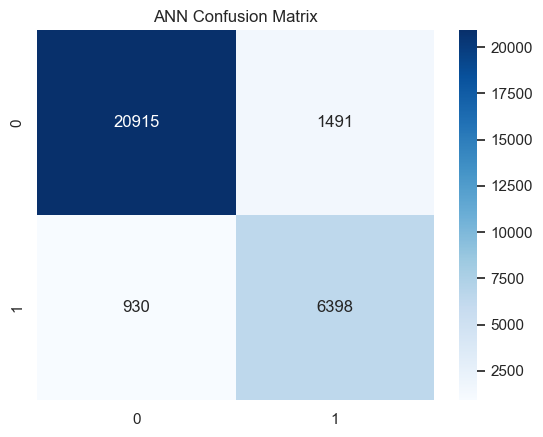

In [42]:
# Evaluate model performance
print("Accuracy:")
print(accuracy_score(y_test, y_pred_ann))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_ann))

# Visualize confusion matrix for ANN
sns.heatmap(
    confusion_matrix(y_test, y_pred_ann),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("ANN Confusion Matrix")
plt.show()

### **3. Deep Neural Network (DNN) Model**

#### **Build and Compile Model**

In [43]:
# Build a simple ANN model
dnn_model = Sequential([
    Dense(128, activation='relu',
          input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the model
dnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### **Train DNN and Predict**

In [44]:
# Train the model with class weights to handle imbalance
history_dnn = dnn_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

# Predict probabilities and classes for the test set
y_prob_dnn = dnn_model.predict(X_test_scaled)
y_pred_dnn = (y_prob_dnn > 0.5).astype(int)

Epoch 1/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8515 - loss: 0.3938 - val_accuracy: 0.8956 - val_loss: 0.2958
Epoch 2/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8807 - loss: 0.3181 - val_accuracy: 0.9018 - val_loss: 0.2662
Epoch 3/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8880 - loss: 0.2974 - val_accuracy: 0.8999 - val_loss: 0.2594
Epoch 4/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8941 - loss: 0.2865 - val_accuracy: 0.9013 - val_loss: 0.2547
Epoch 5/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8961 - loss: 0.2770 - val_accuracy: 0.9054 - val_loss: 0.2453
Epoch 6/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8978 - loss: 0.2717 - val_accuracy: 0.9106 - val_loss: 0.2325
Epoch 7/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8982 - loss: 0.2695 - val_accuracy: 0.9071 - val_loss: 0.2372
Epoch 8/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9001 - loss: 0.2636 - 

#### **Evaluation**

Accuracy:
0.9186116903208448

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95     22406
           1       0.81      0.88      0.84      7328

    accuracy                           0.92     29734
   macro avg       0.88      0.91      0.89     29734
weighted avg       0.92      0.92      0.92     29734


ROC-AUC Score:
0.9679458245890546


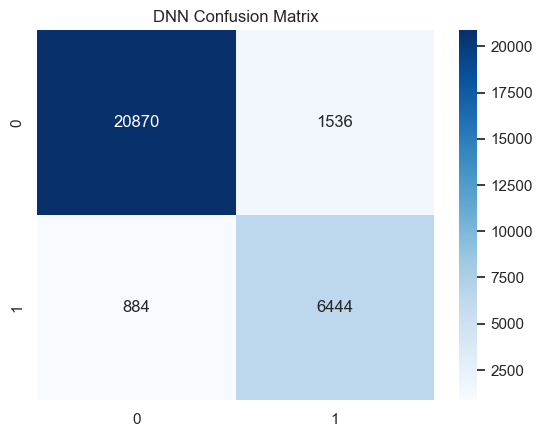

In [45]:
# Evaluate model performance
print("Accuracy:")
print(accuracy_score(y_test, y_pred_dnn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dnn))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_dnn))

# Visualize confusion matrix for DNN
sns.heatmap(
    confusion_matrix(y_test, y_pred_dnn),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("DNN Confusion Matrix")
plt.show()

### **2. Multilayer-Perceptron Model**

#### **Import Libraries**

In [47]:
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

#### **Build MLP Model**

In [ ]:
# Build a more complex ANN model with Batch Normalization and Dropout
mlp_model = Sequential([
    Dense(
        128,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.3),
    
    Dense(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        32,
        activation='relu'
    ),

    Dropout(0.2),

    Dense(
        1,
        activation='sigmoid'
    )
])

#### **Compile Model**

In [49]:
# Compile the model
mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

#### **View Model Summary & Implement Early Stopping**

In [50]:
# Display model architecture
mlp_model.summary()

# Define early stopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,097 (78.50 KB)

 Trainable params: 19,713 (77.00 KB)

 Non-trainable params: 384 (1.50 KB)

#### **Train Model**

In [51]:
history = mlp_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8074 - auc: 0.8581 - loss: 0.4550 - val_accuracy: 0.8844 - val_auc: 0.9183 - val_loss: 0.3227
Epoch 2/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8640 - auc: 0.9114 - loss: 0.3603 - val_accuracy: 0.8931 - val_auc: 0.9375 - val_loss: 0.2863
Epoch 3/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8793 - auc: 0.9305 - loss: 0.3237 - val_accuracy: 0.9044 - val_auc: 0.9509 - val_loss: 0.2589
Epoch 4/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8852 - auc: 0.9401 - loss: 0.3025 - val_accuracy: 0.9075 - val_auc: 0.9543 - val_loss: 0.2395
Epoch 5/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8897 - auc: 0.9448 - loss: 0.2911 - val_accuracy: 0.9100 - val_auc: 0.9567 - val_loss: 0.2377
Epoch 6/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8929 - auc: 0.9490 - loss: 0.2807 - val_accuracy: 0.9073 - val_auc: 0.9594 - val_loss: 0.2378
Epoch 7/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 

#### **Do Prediction**

In [52]:
# Predict probabilities and classes for the test set
test_loss, test_acc, test_auc = mlp_model.evaluate(
    X_test_scaled,
    y_test
)

# Display test accuracy and AUC
print("Test Accuracy:", test_acc)
print("Test AUC:", test_auc)

# Predict probabilities and classes for the test set
y_pred_prob = mlp_model.predict(
    X_test_scaled
)
y_pred = (y_pred_prob > 0.5).astype(int)

930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 743us/step - accuracy: 0.9174 - auc: 0.9677 - loss: 0.2085
Test Accuracy: 0.917434573173523
Test AUC: 0.9677156805992126
930/930 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step


#### **Evaluation**

In [53]:
# Evaluate model performance
print(classification_report(
    y_test,
    y_pred
))

# Calculate ROC-AUC score
auc_score = roc_auc_score(
    y_test,
    y_pred_prob
)

print("ROC-AUC Score:", auc_score)

# Visualize confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

              precision    recall  f1-score   support

           0       0.96      0.93      0.94     22406
           1       0.80      0.88      0.84      7328

    accuracy                           0.92     29734
   macro avg       0.88      0.90      0.89     29734
weighted avg       0.92      0.92      0.92     29734

ROC-AUC Score: 0.9677288732119868
[[20834  1572]
 [  883  6445]]


### **5. Auto-Encoder Model**

### **6. Model Comparison**

In [46]:
# Compile results into a DataFrame for comparison
results = pd.DataFrame({

    'Model': [
        'XGBoost',
        'ANN',
        'DNN'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_ann),
        accuracy_score(y_test, y_pred_dnn)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_ann),
        roc_auc_score(y_test, y_prob_dnn)
    ]
})

results

,Model,Accuracy,ROC-AUC
0,XGBoost,0.975886,0.992579
1,ANN,0.918578,0.966108
2,DNN,0.918612,0.967946
